<a href="https://colab.research.google.com/github/vrundan7/carla-ml-safety/blob/main/per_class_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/2026 (1)/2026"

import os
import csv
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

MODEL_DIR = f"{BASE_PATH}/model_outputs"
LABELS = ['has_traffic_light', 'has_pedestrian', 'has_vehicle']
BATCH_SIZE = 32

# All test splits
TEST_SPLITS = {
    "test":          {"csv": f"{BASE_PATH}/test/test/labels.csv",
                      "img": f"{BASE_PATH}/test/test/rgb-front"},
    "test-fog":      {"csv": f"{BASE_PATH}/test-fog/test-fog/labels.csv",
                      "img": f"{BASE_PATH}/test-fog/test-fog/rgb-front"},
    "test-night":    {"csv": f"{BASE_PATH}/test-night/test-night/labels.csv",
                      "img": f"{BASE_PATH}/test-night/test-night/rgb-front"},
    "test-town-01":  {"csv": f"{BASE_PATH}/test-town-01/test-town-01/labels.csv",
                      "img": f"{BASE_PATH}/test-town-01/test-town-01/rgb-front"},
}

print("Test splits found:")
for name, paths in TEST_SPLITS.items():
    exists = "✅" if os.path.exists(paths["csv"]) else "❌"
    print(f"  {exists} {name}")



Mounted at /content/drive
Device: cuda
Test splits found:
  ✅ test
  ✅ test-fog
  ✅ test-night
  ✅ test-town-01


Dataset & Model Loader

In [2]:
class DrivingDataset(Dataset):
    def __init__(self, csv_path, img_dir, label_col, transform=None):
        self.transform = transform
        self.samples = []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def load_model(label_col):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 1)
    path = os.path.join(MODEL_DIR, f"best_{label_col}.pth")
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def get_predictions(model, loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            preds = (torch.sigmoid(out).squeeze() > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
    return np.array(all_labels), np.array(all_preds)

print("✅ Functions defined.")



✅ Functions defined.


Evaluate All Models on ALL Test Splits

In [3]:

all_results = []  # list of dicts: {split, label, accuracy, precision, recall, f1, cm}

for split_name, split_paths in TEST_SPLITS.items():
    if not os.path.exists(split_paths["csv"]):
        print(f"\n⚠️  Skipping {split_name} — not found")
        continue

    print(f"\n{'#'*70}")
    print(f"#  TEST SPLIT: {split_name}")
    print(f"{'#'*70}")

    for label_col in LABELS:
        model = load_model(label_col)
        test_ds = DrivingDataset(split_paths["csv"], split_paths["img"],
                                 label_col, test_transform)
        nw = 2 if torch.cuda.is_available() else 0
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=nw, pin_memory=torch.cuda.is_available())

        y_true, y_pred = get_predictions(model, test_loader)

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)
        cm   = confusion_matrix(y_true, y_pred)

        tag = label_col.replace('has_','').replace('_',' ').title()
        print(f"\n  {tag}:  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")

        all_results.append({
            'split': split_name, 'label': label_col,
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'cm': cm
        })

print("\n✅ Evaluation complete.")



######################################################################
#  TEST SPLIT: test
######################################################################

  Traffic Light:  Acc=0.9469  Prec=0.9450  Rec=0.9834  F1=0.9638

  Pedestrian:  Acc=0.6553  Prec=0.2963  Rec=0.5510  F1=0.3853

  Vehicle:  Acc=0.8761  Prec=0.9665  Rec=0.8648  F1=0.9128

######################################################################
#  TEST SPLIT: test-fog
######################################################################

  Traffic Light:  Acc=0.3717  Prec=0.9417  Rec=0.1478  F1=0.2554

  Pedestrian:  Acc=0.7378  Prec=0.3050  Rec=0.2251  F1=0.2590

  Vehicle:  Acc=0.6036  Prec=0.9949  Rec=0.4901  F1=0.6567

######################################################################
#  TEST SPLIT: test-night
######################################################################

  Traffic Light:  Acc=0.3481  Prec=0.9965  Rec=0.1070  F1=0.1932

  Pedestrian:  Acc=0.6342  Prec=0.2673  Rec=0.4590  F1=0

Confusion Matrices — Grid (4 splits × 3 models)

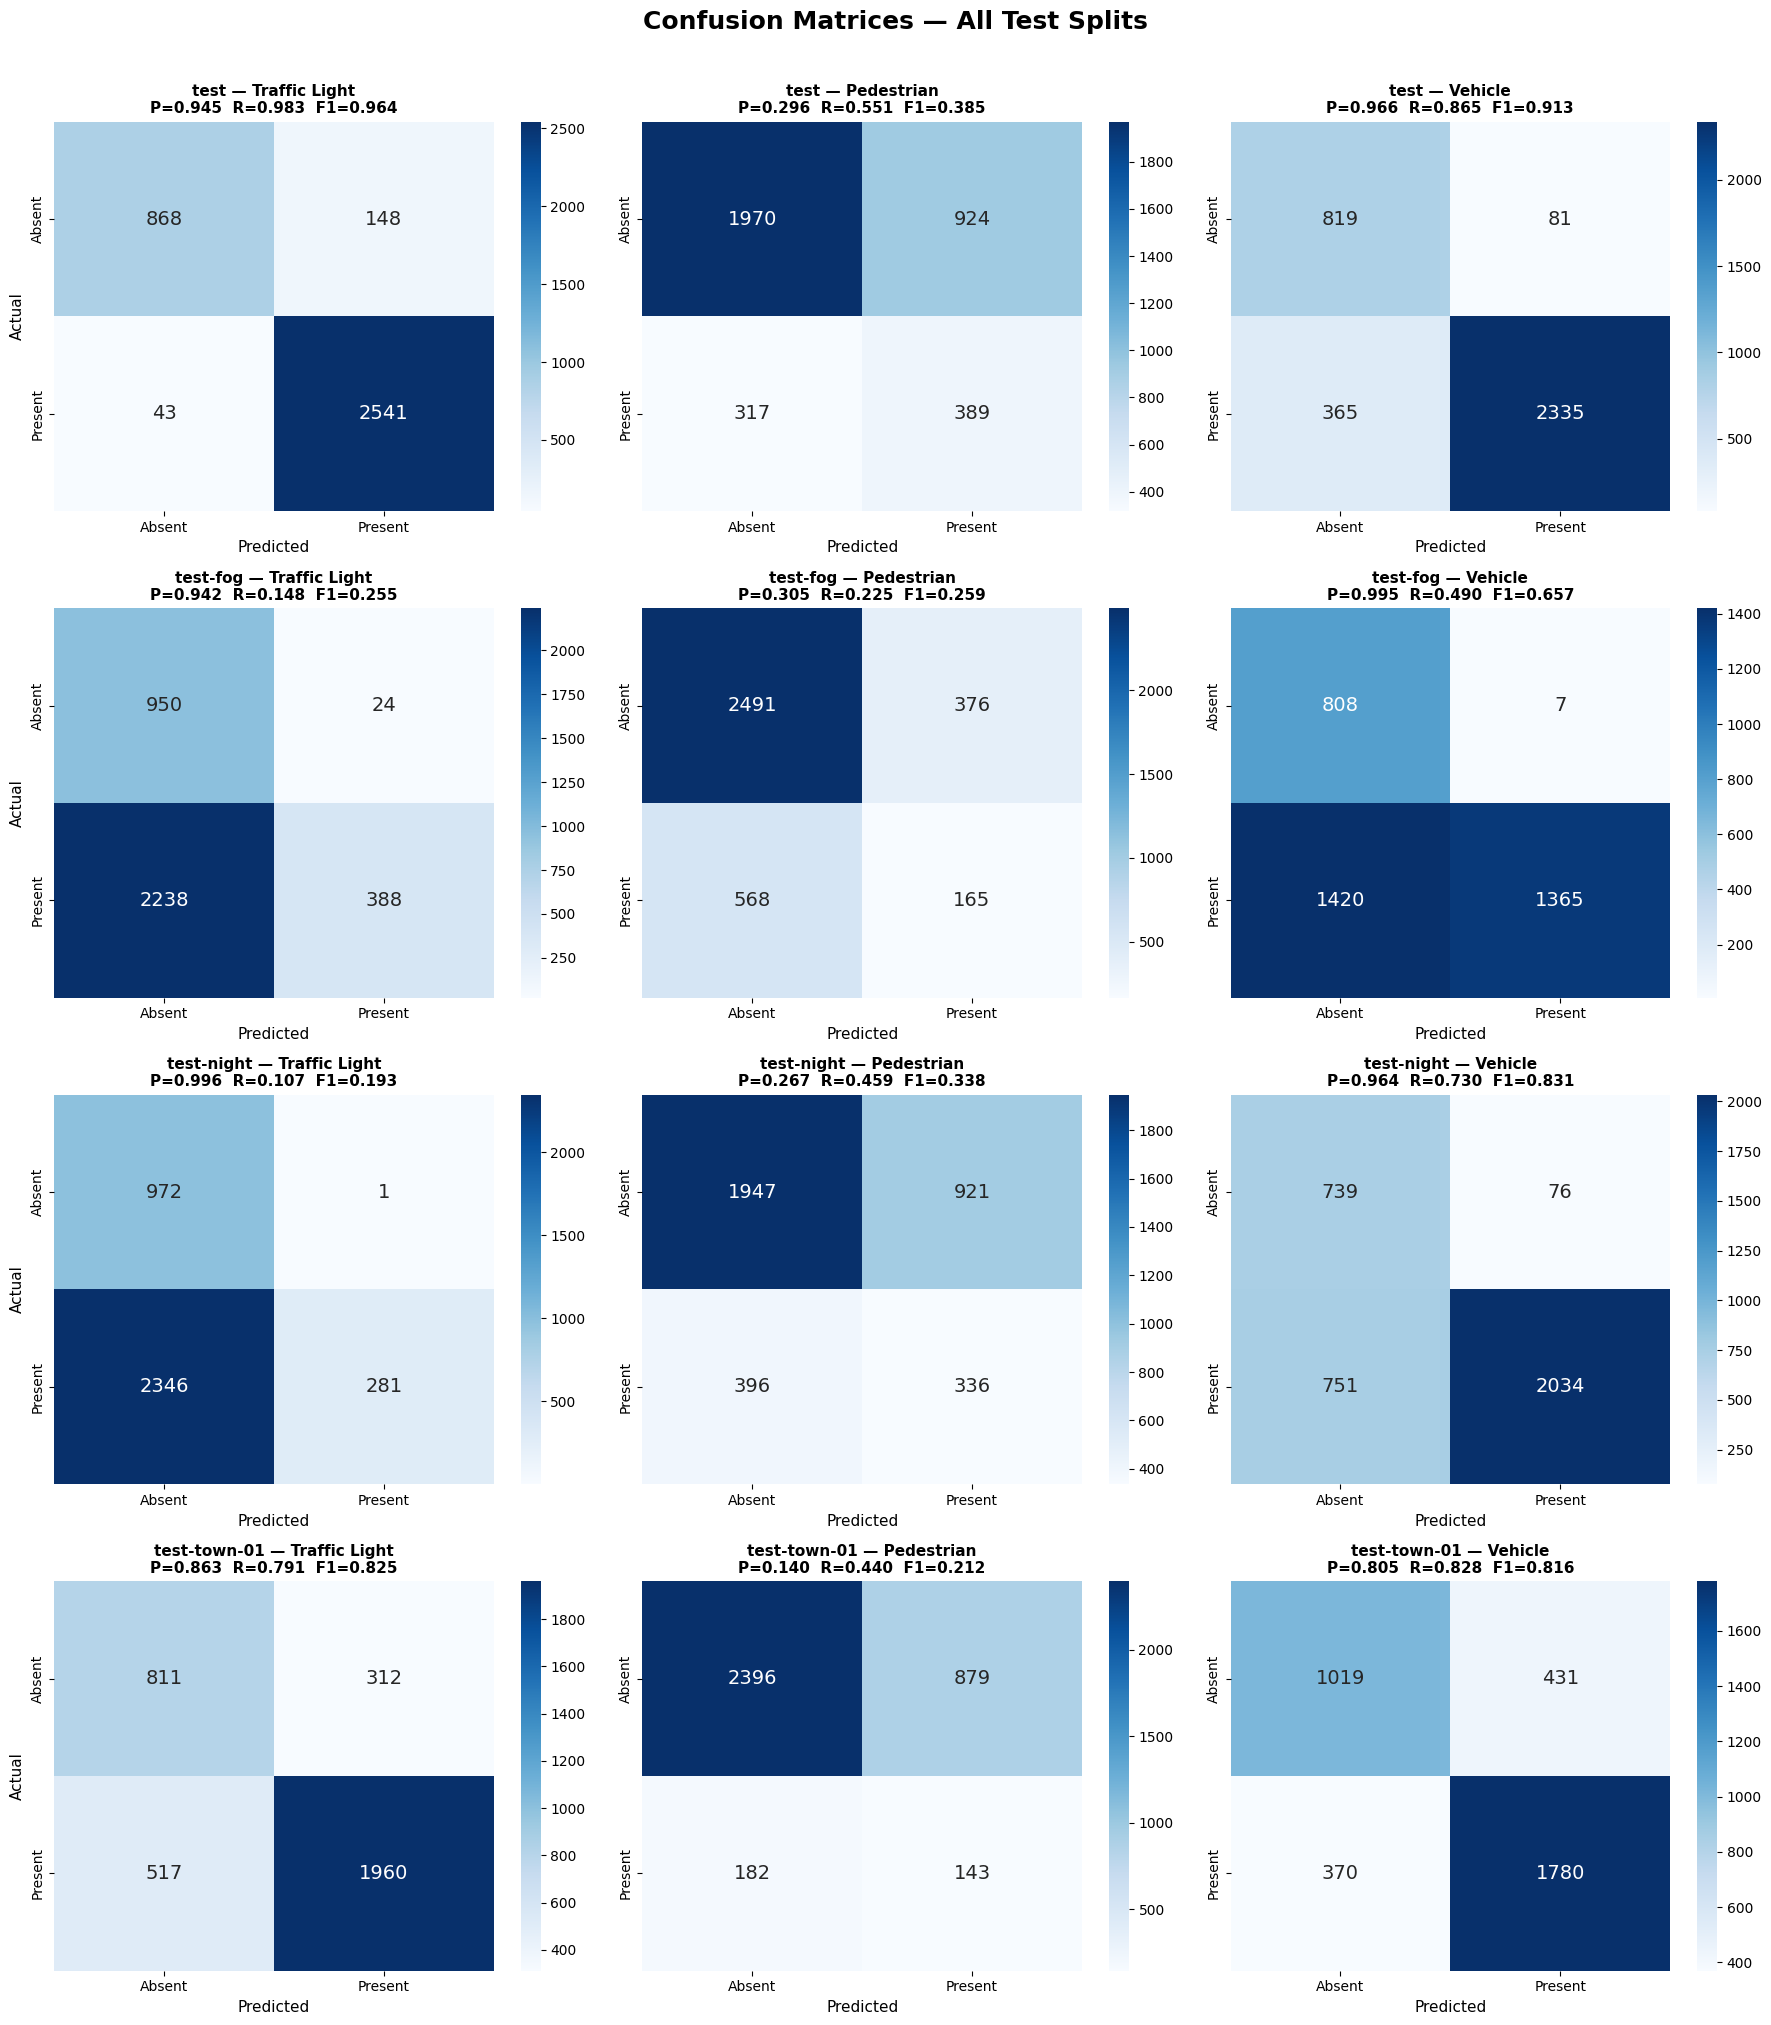

In [4]:

split_names = [s for s in TEST_SPLITS if os.path.exists(TEST_SPLITS[s]["csv"])]
n_splits = len(split_names)

fig, axes = plt.subplots(n_splits, 3, figsize=(18, 5 * n_splits))
if n_splits == 1:
    axes = [axes]  # make it 2D

for row, split_name in enumerate(split_names):
    for col, label_col in enumerate(LABELS):
        r = next(r for r in all_results
                 if r['split'] == split_name and r['label'] == label_col)
        ax = axes[row][col]

        sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Absent', 'Present'],
                    yticklabels=['Absent', 'Present'],
                    annot_kws={"size": 14})

        tag = label_col.replace('has_','').replace('_',' ').title()
        ax.set_title(f"{split_name} — {tag}\n"
                     f"P={r['precision']:.3f}  R={r['recall']:.3f}  F1={r['f1']:.3f}",
                     fontsize=11, fontweight='bold')
        ax.set_ylabel('Actual' if col == 0 else '', fontsize=11)
        ax.set_xlabel('Predicted', fontsize=11)

plt.suptitle('Confusion Matrices — All Test Splits', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/confusion_matrices_all.png", dpi=150, bbox_inches='tight')
plt.show()


Summary Table — All Splits × All Models

In [5]:

print("\n" + "="*95)
print(f"{'Split':<18} {'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*95)
for r in all_results:
    print(f"{r['split']:<18} {r['label']:<25} {r['accuracy']:<12.4f} "
          f"{r['precision']:<12.4f} {r['recall']:<12.4f} {r['f1']:<12.4f}")
print("="*95)

# Lowest recall overall
worst = min(all_results, key=lambda x: x['recall'])
print(f"\n📉 Lowest Recall Overall: {worst['label']} on {worst['split']}  "
      f"(Recall = {worst['recall']:.4f})")



Split              Model                     Accuracy     Precision    Recall       F1-Score    
-----------------------------------------------------------------------------------------------
test               has_traffic_light         0.9469       0.9450       0.9834       0.9638      
test               has_pedestrian            0.6553       0.2963       0.5510       0.3853      
test               has_vehicle               0.8761       0.9665       0.8648       0.9128      
test-fog           has_traffic_light         0.3717       0.9417       0.1478       0.2554      
test-fog           has_pedestrian            0.7378       0.3050       0.2251       0.2590      
test-fog           has_vehicle               0.6036       0.9949       0.4901       0.6567      
test-night         has_traffic_light         0.3481       0.9965       0.1070       0.1932      
test-night         has_pedestrian            0.6342       0.2673       0.4590       0.3379      
test-night         has_vehicle

Recall Comparison Across Splits (grouped bar chart)

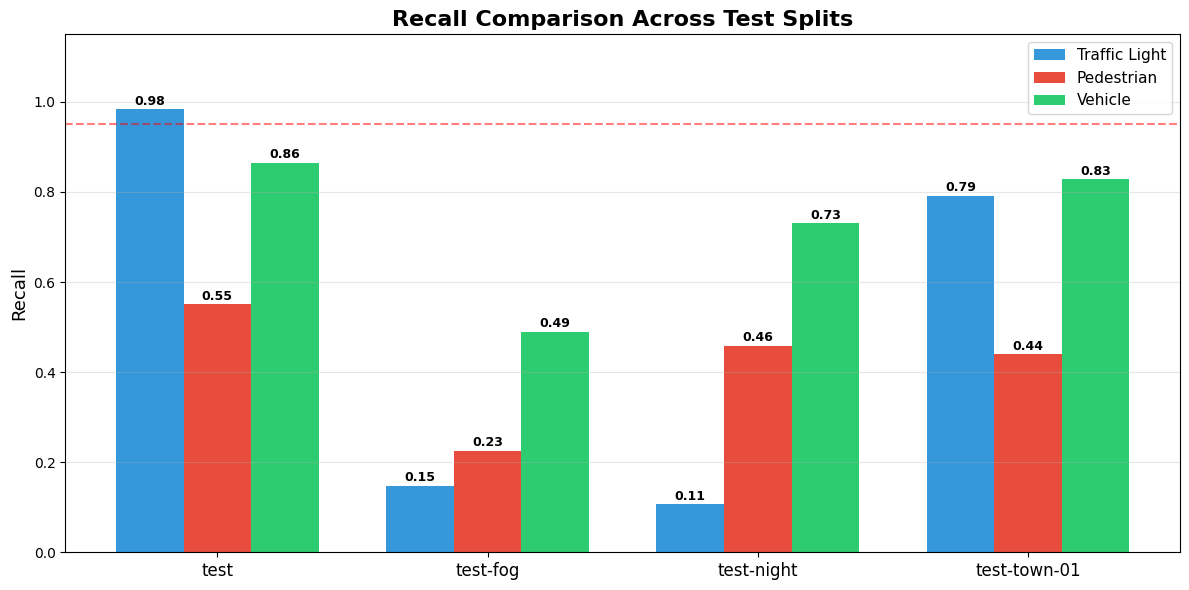

In [6]:

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(split_names))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, label_col in enumerate(LABELS):
    recalls = []
    for split_name in split_names:
        r = next(r for r in all_results
                 if r['split'] == split_name and r['label'] == label_col)
        recalls.append(r['recall'])

    tag = label_col.replace('has_','').replace('_',' ').title()
    bars = ax.bar(x + i * width, recalls, width, label=tag, color=colors[i])

    for bar, val in zip(bars, recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Recall', fontsize=13)
ax.set_title('Recall Comparison Across Test Splits', fontsize=16, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(split_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='Safety threshold (0.95)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/recall_comparison.png", dpi=150, bbox_inches='tight')
plt.show()



F1 Comparison Across Splits

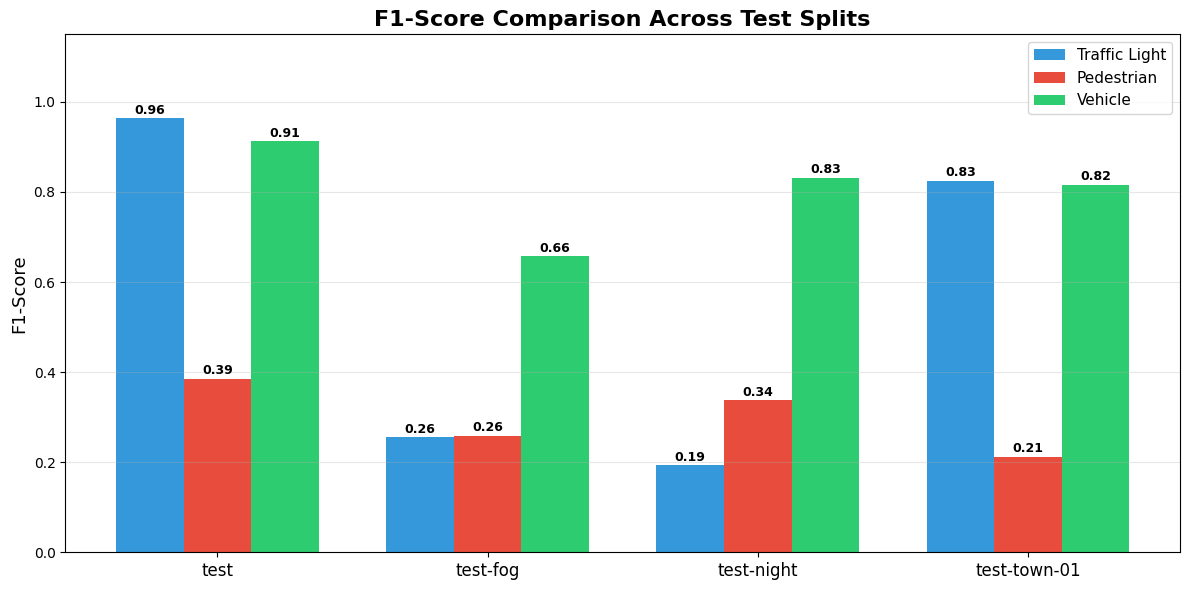

In [7]:

fig, ax = plt.subplots(figsize=(12, 6))

for i, label_col in enumerate(LABELS):
    f1s = []
    for split_name in split_names:
        r = next(r for r in all_results
                 if r['split'] == split_name and r['label'] == label_col)
        f1s.append(r['f1'])

    tag = label_col.replace('has_','').replace('_',' ').title()
    bars = ax.bar(x + i * width, f1s, width, label=tag, color=colors[i])

    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('F1-Score', fontsize=13)
ax.set_title('F1-Score Comparison Across Test Splits', fontsize=16, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(split_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/f1_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


Safety Argument — Minimum Recall for Pedestrian Model

Required minimum recall: ≥ 0.95 (95%)

Justification:

SEVERITY: Missing a pedestrian (false negative) can directly lead to a fatal collision — the highest severity outcome in ISO 26262 (ASIL D).

EXPOSURE: Pedestrians appear in ~24% of frames. A recall of 0.95 means at most 5% of pedestrian-present frames are missed. At 10 FPS, this is 1 missed frame every 2 seconds — still risky, but downstream tracking can compensate.

CONTROLLABILITY: Unlike vehicles (which move predictably), pedestrians can change direction suddenly. The system has very little time to react, so detection must be near-perfect.

COMPARISON: Industry standards for pedestrian detection (e.g., Euro NCAP AEB Pedestrian) require >95% detection rate in standard test scenarios.

COST OF FALSE NEGATIVES vs FALSE POSITIVES:
False negative = potential fatality
False positive = unnecessary braking (inconvenient but safe)

→ We strongly prefer high recall even at the cost of lower precision.

CONCLUSION: A recall below 0.95 for pedestrian detection is unacceptable for deployment. The model should be retrained with more pedestrian data, lower classification threshold, or ensemble methods before any deployment consideration.

In [9]:

# Check each split
print("Pedestrian Recall per Split:")
print("-"*50)
for split_name in split_names:
    r = next(r for r in all_results
             if r['split'] == split_name and r['label'] == 'has_pedestrian')
    status = "✅ PASS" if r['recall'] >= 0.95 else "❌ FAIL"
    print(f"  {split_name:<18} Recall = {r['recall']:.4f}  {status}")


Pedestrian Recall per Split:
--------------------------------------------------
  test               Recall = 0.5510  ❌ FAIL
  test-fog           Recall = 0.2251  ❌ FAIL
  test-night         Recall = 0.4590  ❌ FAIL
  test-town-01       Recall = 0.4400  ❌ FAIL
